In [5]:
# === Cell 1: Imports & configuration ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display & plot settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

print("Setup complete. pandas", pd.__version__)

Setup complete. pandas 3.0.3


In [6]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn jupyter openpyxl ipykernel


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# === Cell 2: Load raw data (anchored to project root) ===
import os

print("Notebook is running from:", os.getcwd())

candidate_paths = [
    "data/raw/Utility_consumption.csv",                         # workspace = project root
    "../data/raw/Utility_consumption.csv",                      # workspace = notebooks/
    "apu-load-forecasting/data/raw/Utility_consumption.csv",    # workspace = parent (c:\Project1)
]

RAW_PATH = next((p for p in candidate_paths if os.path.exists(p)), None)
if RAW_PATH is None:
    raise FileNotFoundError(
        "Could not find the CSV.\nCurrent dir: " + os.getcwd()
        + "\nLooked in: " + str(candidate_paths)
    )

print("Found data at:", os.path.abspath(RAW_PATH))

df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
print("\n--- First 3 rows ---");  print(df.head(3))
print("\n--- Last 3 rows ---");   print(df.tail(3))
print("\n--- Dtypes ---");        print(df.dtypes)
print("\n--- Info ---");          df.info()

Notebook is running from: c:\Project1\apu-load-forecasting\notebooks
Found data at: c:\Project1\apu-load-forecasting\data\raw\Utility_consumption.csv
Shape: (52416, 7)

--- First 3 rows ---
           Datetime  Temperature  Humidity  WindSpeed  F1_132KV_PowerConsumption  F2_132KV_PowerConsumption  \
0  01-01-2017 00:00        6.559      73.8      0.083                34055.69620                16128.87538   
1  01-01-2017 00:10        6.414      74.5      0.083                29814.68354                19375.07599   
2  01-01-2017 00:20        6.313      74.5      0.080                29128.10127                19006.68693   

   F3_132KV_PowerConsumption  
0                20240.96386  
1                20131.08434  
2                19668.43373  

--- Last 3 rows ---
               Datetime  Temperature  Humidity  WindSpeed  F1_132KV_PowerConsumption  F2_132KV_PowerConsumption  \
52413  12/30/2017 23:30        6.900      72.8      0.086                29590.87452                25277

In [8]:
# How many rows use '/' vs '-' as the separator?
has_slash = df['Datetime'].str.contains('/')
print("Rows with '/' (slash, looks like m/d/yyyy):", has_slash.sum())
print("Rows with '-' (dash,  looks like dd-mm-yyyy):", (~has_slash).sum())

# Show examples of each
print("\nExample dash-format rows:")
print(df.loc[~has_slash, 'Datetime'].head(3).tolist())
print("\nExample slash-format rows:")
print(df.loc[has_slash, 'Datetime'].head(3).tolist())

# Find exactly where the format switches
first_slash_idx = df.index[has_slash][0]
print("\nFormat switches at row index:", first_slash_idx)
print("Rows around the switch:")
print(df['Datetime'].iloc[first_slash_idx-2 : first_slash_idx+3].tolist())

Rows with '/' (slash, looks like m/d/yyyy): 31680
Rows with '-' (dash,  looks like dd-mm-yyyy): 20736

Example dash-format rows:
['01-01-2017 00:00', '01-01-2017 00:10', '01-01-2017 00:20']

Example slash-format rows:
['1/13/2017 0:00', '1/13/2017 0:10', '1/13/2017 0:20']

Format switches at row index: 1728
Rows around the switch:
['01-12-2017 23:40', '01-12-2017 23:50', '1/13/2017 0:00', '1/13/2017 0:10', '1/13/2017 0:20']


In [9]:
# === Cell 4: Why a naive parse corrupts the data ===

# The WRONG way most people do it (force a single format / let pandas guess one way)
naive = pd.to_datetime(df['Datetime'], dayfirst=True, format='%d-%m-%Y %H:%M', errors='coerce')
print("Naive single-format parse ('%d-%m-%Y %H:%M'):")
print("  Successfully parsed :", naive.notna().sum())
print("  Turned into NaT     :", naive.isna().sum(), "  <-- silently lost rows!")

# The CORRECT way: let pandas handle each row's format, day-first where ambiguous
correct = pd.to_datetime(df['Datetime'], format='mixed', dayfirst=True, errors='coerce')
print("\nCorrect mixed-format parse:")
print("  Successfully parsed :", correct.notna().sum())
print("  Turned into NaT     :", correct.isna().sum())
print("  Min date:", correct.min())
print("  Max date:", correct.max())

Naive single-format parse ('%d-%m-%Y %H:%M'):
  Successfully parsed : 20736
  Turned into NaT     : 31680   <-- silently lost rows!

Correct mixed-format parse:
  Successfully parsed : 52416
  Turned into NaT     : 0
  Min date: 2017-01-01 00:00:00
  Max date: 2017-12-30 23:50:00


In [10]:
# Apply the verified mixed-format parse to the real dataframe
df['Datetime'] = pd.to_datetime(df['Datetime'], format='mixed', dayfirst=True, errors='coerce')

# Confirm no parsing failures slipped through
assert df['Datetime'].isna().sum() == 0, "Some datetimes failed to parse!"

# Is the timeline strictly increasing (each row later than the previous)?
is_sorted = df['Datetime'].is_monotonic_increasing
print("Timeline strictly increasing:", is_sorted)

# Any exact duplicate timestamps?
dupes = df['Datetime'].duplicated().sum()
print("Duplicate timestamps:", dupes)

# Set Datetime as the index (standard for time series work)
df = df.set_index('Datetime').sort_index()
print("\nIndex set. Range:", df.index.min(), "->", df.index.max())
print("Total rows:", len(df))

Timeline strictly increasing: False
Duplicate timestamps: 0

Index set. Range: 2017-01-01 00:00:00 -> 2017-12-30 23:50:00
Total rows: 52416


In [11]:


# Build the *ideal* complete 10-minute timeline from start to end
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='10min')
print("Expected timestamps on a perfect 10-min grid:", len(full_range))
print("Actual timestamps present                   :", len(df))
print("Missing timestamps (gaps in the grid)       :", len(full_range) - len(df))

# If there are gaps, show where they are
missing = full_range.difference(df.index)
if len(missing) > 0:
    print("\nFirst 10 missing timestamps:")
    print(missing[:10].tolist())
else:
    print("\nNo missing timestamps — the 10-minute grid is complete.")

Expected timestamps on a perfect 10-min grid: 52416
Actual timestamps present                   : 52416
Missing timestamps (gaps in the grid)       : 0

No missing timestamps — the 10-minute grid is complete.


In [12]:
# === Cell 7: Confirm the index is now clean after sorting ===

print("Index monotonic increasing now? ", df.index.is_monotonic_increasing)
print("Index unique?                   ", df.index.is_unique)
print("Index length:                   ", len(df.index))

# Verify the spacing between consecutive timestamps is a uniform 10 minutes
deltas = df.index.to_series().diff().dropna()
print("\nUnique gaps between consecutive rows:")
print(deltas.value_counts())

Index monotonic increasing now?  True
Index unique?                    True
Index length:                    52416

Unique gaps between consecutive rows:
Datetime
0 days 00:10:00    52415
Name: count, dtype: int64


In [13]:
# === Cell 8: Missing value check across all columns ===

print("Missing (NaN) values per column:")
print(df.isna().sum())

total_missing = df.isna().sum().sum()
print("\nTotal NaN cells in the dataset:", total_missing)

if total_missing > 0:
    # Show which rows have any missing value
    rows_with_na = df[df.isna().any(axis=1)]
    print("Rows containing at least one NaN:", len(rows_with_na))
    print("\nFirst few such rows:")
    print(rows_with_na.head())

Missing (NaN) values per column:
Temperature                  0
Humidity                     0
WindSpeed                    0
F1_132KV_PowerConsumption    0
F2_132KV_PowerConsumption    0
F3_132KV_PowerConsumption    0
dtype: int64

Total NaN cells in the dataset: 0


In [14]:
# === Cell 9: Statistical summary + physical-plausibility checks ===

print("=== Full statistical summary ===")
print(df.describe().T)   # .T = transpose, easier to read with many columns

print("\n=== Physical plausibility checks ===")

# Power consumption should never be negative or zero (a live feeder always draws something)
for col in ['F1_132KV_PowerConsumption', 'F2_132KV_PowerConsumption', 'F3_132KV_PowerConsumption']:
    neg = (df[col] < 0).sum()
    zero = (df[col] == 0).sum()
    print(f"{col}:  negatives={neg},  exact zeros={zero}")

# Humidity must be within 0–100%
print("\nHumidity < 0   :", (df['Humidity'] < 0).sum())
print("Humidity > 100 :", (df['Humidity'] > 100).sum())

# Temperature: flag anything outside a generous real-world band for Dhanbad (°C)
print("Temperature < -5 :", (df['Temperature'] < -5).sum())
print("Temperature > 50 :", (df['Temperature'] > 50).sum())

# Wind speed should never be negative
print("WindSpeed < 0  :", (df['WindSpeed'] < 0).sum())

=== Full statistical summary ===
                             count          mean          std           min           25%           50%           75%  \
Temperature                52416.0     18.810024     5.815476      3.247000     14.410000     18.780000     22.890000   
Humidity                   52416.0     68.259518    15.551177     11.340000     58.310000     69.860000     81.400000   
WindSpeed                  52416.0      1.959489     2.348862      0.050000      0.078000      0.086000      4.915000   
F1_132KV_PowerConsumption  52416.0  32344.970564  7130.562564  13895.696200  26310.668692  32265.920340  37309.018185   
F2_132KV_PowerConsumption  52416.0  21042.509082  5201.465892   8560.081466  16980.766032  20823.168405  24713.717520   
F3_132KV_PowerConsumption  52416.0  17835.406218  6622.165099   5935.174070  13129.326630  16415.117470  21624.100420   

                                   max  
Temperature                   40.01000  
Humidity                      94.8000

In [15]:
# === Cell 10: Detect flat-lines (consecutive identical values = stuck sensor) ===

def longest_flat_run(series):
    """Return the length of the longest run of identical consecutive values."""
    # True where a value equals the previous value
    same_as_prev = (series == series.shift(1))
    # Count consecutive True streaks
    runs = same_as_prev.ne(same_as_prev.shift()).cumsum()
    streak = same_as_prev.groupby(runs).cumsum()
    return int(streak.max()) + 1 if len(streak) else 0

for col in df.columns:
    run = longest_flat_run(df[col])
    print(f"{col:32s}  longest identical-value run: {run}")

Temperature                       longest identical-value run: 4
Humidity                          longest identical-value run: 9
WindSpeed                         longest identical-value run: 7
F1_132KV_PowerConsumption         longest identical-value run: 3
F2_132KV_PowerConsumption         longest identical-value run: 3
F3_132KV_PowerConsumption         longest identical-value run: 3


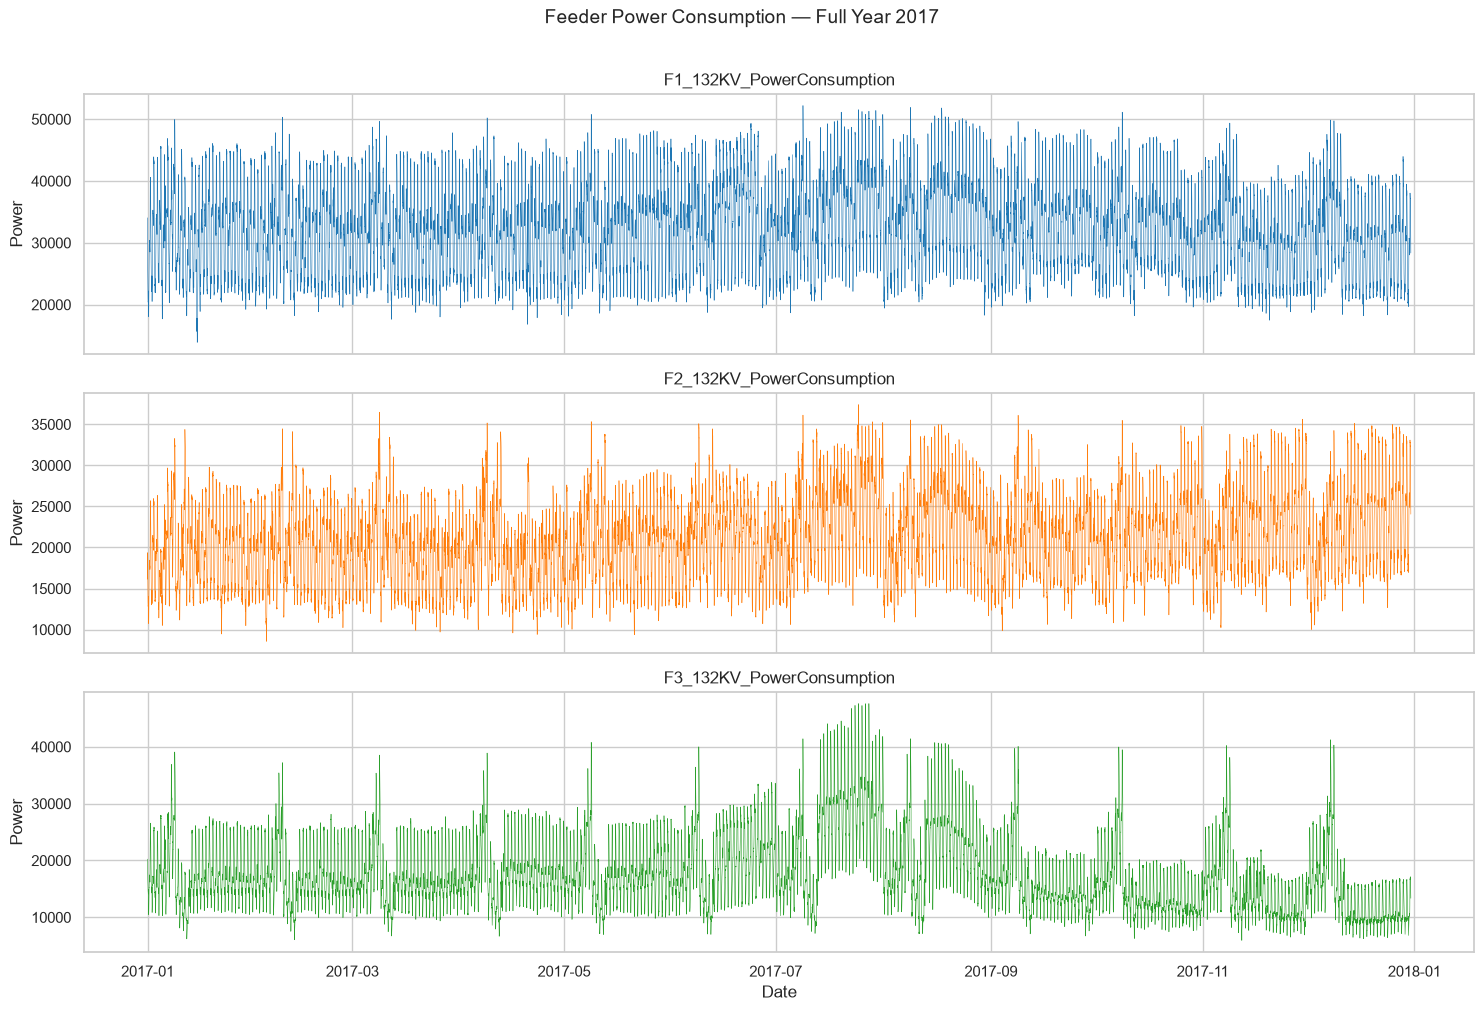

In [16]:
# === Cell 11: Plot the full-year load for each feeder ===

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

feeders = ['F1_132KV_PowerConsumption',
           'F2_132KV_PowerConsumption',
           'F3_132KV_PowerConsumption']
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, col, c in zip(axes, feeders, colors):
    ax.plot(df.index, df[col], color=c, linewidth=0.4)
    ax.set_title(col)
    ax.set_ylabel("Power")

axes[-1].set_xlabel("Date")
plt.suptitle("Feeder Power Consumption — Full Year 2017", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\nirap\AppData\Local\Temp\ipykernel_3352\2618433102.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col], vert=True, patch_artist=True,
C:\Users\nirap\AppData\Local\Temp\ipykernel_3352\2618433102.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col], vert=True, patch_artist=True,
C:\Users\nirap\AppData\Local\Temp\ipykernel_3352\2618433102.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col], vert=True, patch_artist=True,


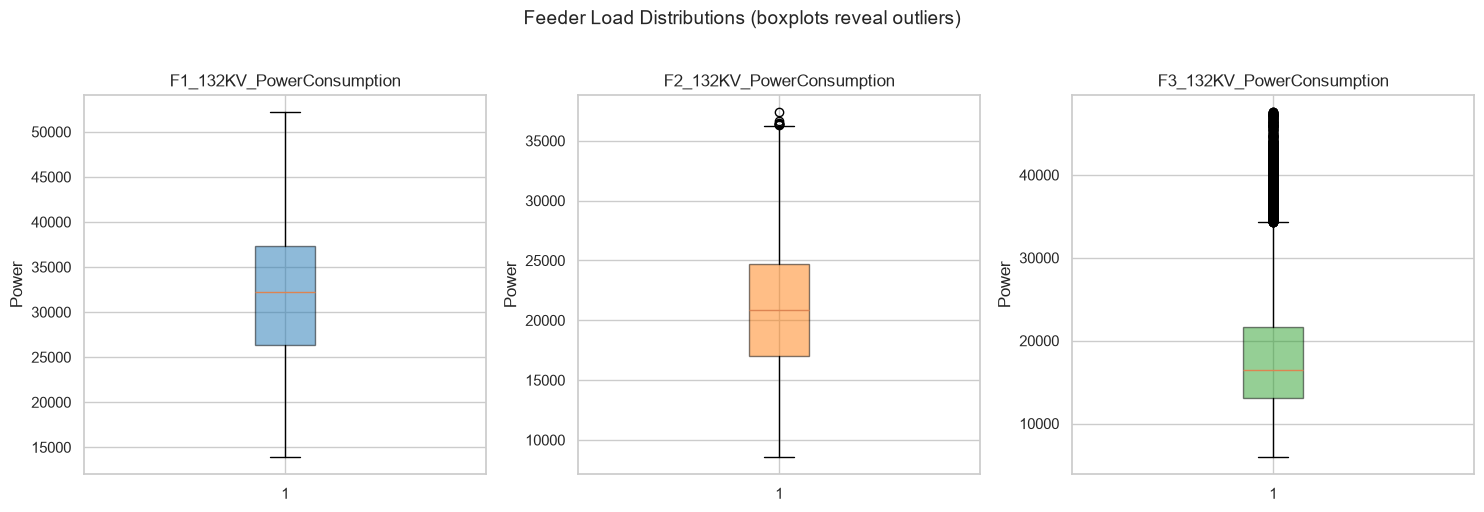

In [17]:
# === Cell 12: Boxplots to visualize spread and outliers per feeder ===

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, c in zip(axes, feeders, colors):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor=c, alpha=0.5))
    ax.set_title(col)
    ax.set_ylabel("Power")

plt.suptitle("Feeder Load Distributions (boxplots reveal outliers)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

F3 maximum value: 47598.32636
Occurred at: 2017-07-24 20:10:00

Readings around the F3 peak:
                     F1_132KV_PowerConsumption  F2_132KV_PowerConsumption  F3_132KV_PowerConsumption
Datetime                                                                                            
2017-07-24 18:10:00                40045.71429                32282.27848                30625.60669
2017-07-24 18:20:00                40001.06312                32339.24051                30715.98326
2017-07-24 18:30:00                40179.66777                32453.16456                30999.16318
2017-07-24 18:40:00                40377.40864                32681.01266                31252.21757
2017-07-24 18:50:00                40651.69435                32631.64557                31535.39749
2017-07-24 19:00:00                41066.31229                32943.03797                32264.43515
2017-07-24 19:10:00                41665.91362                33691.13924                33463.4309

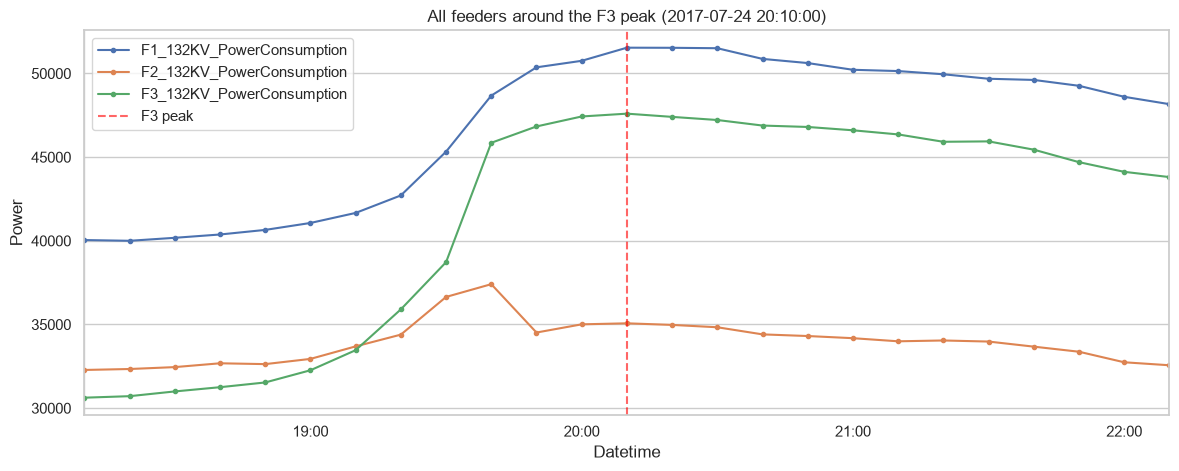

In [18]:
# === Cell 13: Inspect the F3 outlier in its time context ===

# Find the timestamp of the F3 maximum
f3 = 'F3_132KV_PowerConsumption'
peak_time = df[f3].idxmax()
print("F3 maximum value:", df[f3].max())
print("Occurred at:", peak_time)

# Look at a window of ±2 hours (12 ten-minute blocks each side) around the peak
window = df.loc[peak_time - pd.Timedelta(hours=2): peak_time + pd.Timedelta(hours=2), feeders]
print("\nReadings around the F3 peak:")
print(window)

# Plot that window for all three feeders
window.plot(figsize=(14, 5), marker='o', markersize=3)
plt.title(f"All feeders around the F3 peak ({peak_time})")
plt.ylabel("Power")
plt.axvline(peak_time, color='red', linestyle='--', alpha=0.6, label='F3 peak')
plt.legend()
plt.show()

In [19]:
# === Quick kernel sanity check ===
import sys
print(sys.executable)

c:\Project1\apu-load-forecasting\venv\Scripts\python.exe


In [20]:
# === Cell 14: Detect isolated single-point jumps (point differs sharply from BOTH neighbors) ===

for col in feeders:
    s = df[col]
    # Difference from previous and next readings
    diff_prev = (s - s.shift(1)).abs()
    diff_next = (s - s.shift(-1)).abs()
    # A glitch spikes away from BOTH neighbors at once
    # Threshold: jump larger than 5x the typical 10-min change for that feeder
    typical_step = (s.diff().abs()).median()
    threshold = 15 * typical_step   # deliberately generous so we only catch extreme isolated jumps
    spikes = df[(diff_prev > threshold) & (diff_next > threshold)]
    print(f"{col}: typical 10-min step={typical_step:.1f}, "
          f"threshold={threshold:.1f}, isolated spikes found={len(spikes)}")
    if len(spikes) > 0:
        print(spikes[[col]].head(10))
        print("-" * 60)

F1_132KV_PowerConsumption: typical 10-min step=310.0, threshold=4650.2, isolated spikes found=0
F2_132KV_PowerConsumption: typical 10-min step=213.3, threshold=3199.6, isolated spikes found=2
                     F2_132KV_PowerConsumption
Datetime                                      
2017-04-20 12:40:00                25533.60489
2017-11-12 11:00:00                18244.86039
------------------------------------------------------------
F3_132KV_PowerConsumption: typical 10-min step=174.7, threshold=2620.9, isolated spikes found=12
                     F3_132KV_PowerConsumption
Datetime                                      
2017-05-23 12:50:00                15513.52227
2017-06-26 14:20:00                23494.89231
2017-07-13 19:30:00                36530.20921
2017-07-17 19:20:00                36277.15481
2017-07-19 19:30:00                40295.89958
2017-07-24 19:30:00                38723.34728
2017-07-26 19:20:00                40380.25105
2017-07-27 19:20:00                4125

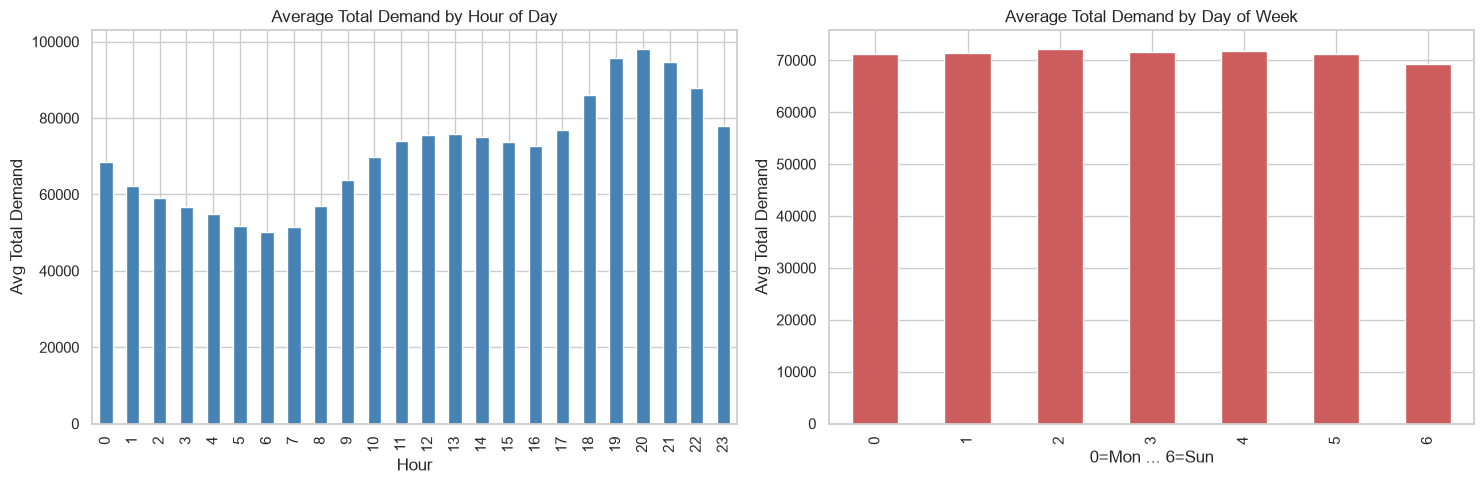

Peak hour: 20 | Trough hour: 6
Busiest day: 2 | Quietest day: 6


In [21]:
# === Cell 15: Average load by hour-of-day and day-of-week ===

# Total demand = the primary target we agreed on
df['Total_Demand'] = df[feeders].sum(axis=1)

# Average total demand by hour of day
hourly = df.groupby(df.index.hour)['Total_Demand'].mean()

# Average total demand by day of week (0=Mon ... 6=Sun)
daily = df.groupby(df.index.dayofweek)['Total_Demand'].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
hourly.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Average Total Demand by Hour of Day")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Avg Total Demand")

daily.plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title("Average Total Demand by Day of Week")
axes[1].set_xlabel("0=Mon ... 6=Sun"); axes[1].set_ylabel("Avg Total Demand")

plt.tight_layout()
plt.show()

print("Peak hour:", hourly.idxmax(), "| Trough hour:", hourly.idxmin())
print("Busiest day:", daily.idxmax(), "| Quietest day:", daily.idxmin())

In [22]:
import sys
print(sys.executable)


c:\Project1\apu-load-forecasting\venv\Scripts\python.exe


                     F1_132KV_PowerConsumption  F2_132KV_PowerConsumption  F3_132KV_PowerConsumption
Datetime                                                                                            
2017-07-26 18:20:00                39127.17608                27394.93671                33933.38912
2017-07-26 18:30:00                39139.93355                27512.65823                34216.56904
2017-07-26 18:40:00                39286.64452                27710.12658                34674.47699
2017-07-26 18:50:00                39178.20598                28025.31646                35337.23849
2017-07-26 19:00:00                39911.76080                28291.13924                36132.55230
2017-07-26 19:10:00                41123.72093                28788.60759                37548.45188
2017-07-26 19:20:00                42106.04651                29692.40506                40380.25105
2017-07-26 19:30:00                44938.20598                31883.54430                43

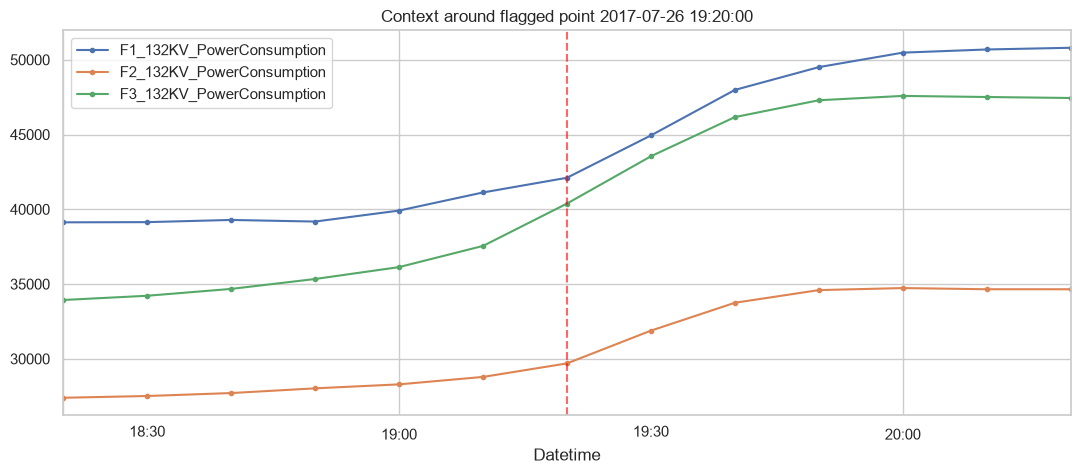

In [23]:
# === Cell 16: Verify a flagged F3 "spike" is part of a real ramp, not a glitch ===
ts = pd.Timestamp("2017-07-26 19:20:00")
window = df.loc[ts - pd.Timedelta(hours=1): ts + pd.Timedelta(hours=1),
                ['F1_132KV_PowerConsumption','F2_132KV_PowerConsumption','F3_132KV_PowerConsumption']]
print(window)
window.plot(figsize=(13,5), marker='o', markersize=3, title=f"Context around flagged point {ts}")
plt.axvline(ts, color='red', linestyle='--', alpha=0.6)
plt.show()

## Data Quality Investigation & Cleaning Summary

**Dataset:** 52,416 rows · 10-minute intervals · full-year 2017 (Jan 1 – Dec 30) · 3 weather + 3 feeder columns.

### Issues found and how we handled them

1. **Datetime corruption (the only real defect) — FIXED.**
   The `Datetime` column mixed two formats: rows for Jan 1–12 used `dd-mm-yyyy` (dash),
   then the file switched to `m/d/yyyy` (slash) from Jan 13 onward. A naive single-format
   parse silently corrupted 31,680 of 52,416 rows (60%) into invalid dates.
   Additionally, rows were not in chronological order in the raw file.
   *Resolution:* parsed with `format='mixed', dayfirst=True` (recovered 100% of rows,
   0 failures), set as a datetime index, and sorted chronologically.

2. **Timeline integrity — VERIFIED CLEAN.**
   After sorting: index is strictly increasing, unique, and perfectly spaced — all 52,415
   gaps between consecutive rows are exactly 10 minutes. No missing timestamps.

3. **Missing values — NONE.** Zero NaN cells across all six columns.

4. **Impossible values — NONE.** No negative/zero power, humidity within 0–100%,
   temperature and wind within physical bounds.

5. **Stuck sensors (flat-lines) — NONE.** Longest run of identical consecutive values
   was 3 (power) and 9 (humidity) — normal physical behavior, not frozen sensors.

6. **Outliers — INVESTIGATED, RETAINED.** The most extreme values (e.g. F3 peak of
   47,598 on 2017-07-24 20:10) were verified as **real demand events**, not errors:
   they are smooth multi-hour ramps correlated across all three feeders, consistent with
   summer evening cooling load. Classical (boxplot/IQR) outlier flags were rejected because
   they ignore the strong daily/seasonal cyclicality inherent to load data.

### Patterns identified (for feature engineering)
- **Strong daily cycle:** demand troughs ~06:00 (~50,000) and peaks ~20:00 (~98,000).
- **Strong seasonality:** F3 shows a pronounced summer (Jun–Aug) cooling-load hump.
- **Weak weekday effect:** average demand is nearly flat across days of the week
  (busiest Wed, quietest Sun), suggesting industrial/baseload-dominated consumption.

### Conclusion
The dataset required **one** substantive cleaning operation (datetime repair + sort).
Values were otherwise clean. No rows were dropped or imputed.

In [24]:
# === Cell 17: Save the cleaned dataset for downstream phases ===
import os

out_dir = "../data/processed"
os.makedirs(out_dir, exist_ok=True)   # safe even if it exists

out_path = os.path.join(out_dir, "utility_cleaned.csv")
df.to_csv(out_path)   # index (Datetime) is written as the first column

print("Saved cleaned data to:", os.path.abspath(out_path))
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nQuick reload check:")
check = pd.read_csv(out_path, index_col='Datetime', parse_dates=['Datetime'])
print("Reloaded shape:", check.shape, "| index is datetime:", check.index.dtype)

Saved cleaned data to: c:\Project1\apu-load-forecasting\data\processed\utility_cleaned.csv
Shape: (52416, 7)
Columns: ['Temperature', 'Humidity', 'WindSpeed', 'F1_132KV_PowerConsumption', 'F2_132KV_PowerConsumption', 'F3_132KV_PowerConsumption', 'Total_Demand']

Quick reload check:
Reloaded shape: (52416, 7) | index is datetime: datetime64[us]


In [1]:
import sys
!{sys.executable} -m pip install requests
print("Done.")

Done.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# === Cell 19: Connectivity test — fetch ONE day of Dhanbad weather ===
import requests

LAT, LON = 23.7957, 86.4304   # Dhanbad, Jharkhand

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": "2017-01-01",
    "end_date": "2017-01-01",
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,cloud_cover",
    "timezone": "Asia/Kolkata",
}

resp = requests.get(url, params=params, timeout=30)
print("HTTP status:", resp.status_code)   # 200 = success

data = resp.json()
print("Keys returned:", list(data.keys()))
print("Hourly variables:", list(data.get("hourly", {}).keys()))

# Show the first 3 hours
h = data["hourly"]
for i in range(3):
    print(f"{h['time'][i]}  temp={h['temperature_2m'][i]}°C  "
          f"humidity={h['relative_humidity_2m'][i]}%  "
          f"wind={h['wind_speed_10m'][i]}  cloud={h['cloud_cover'][i]}%")

HTTP status: 200
Keys returned: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly']
Hourly variables: ['time', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'cloud_cover']
2017-01-01T00:00  temp=14.7°C  humidity=89%  wind=6.8  cloud=18%
2017-01-01T01:00  temp=14.4°C  humidity=92%  wind=6.4  cloud=23%
2017-01-01T02:00  temp=14.2°C  humidity=94%  wind=5.6  cloud=23%


In [3]:
# === Cell 20: Fetch full-year 2017 Dhanbad weather and cache to disk ===
import os
import requests
import pandas as pd

LAT, LON = 23.7957, 86.4304
CACHE_PATH = "../data/raw/dhanbad_weather_2017.csv"

if os.path.exists(CACHE_PATH):
    print("Cache found — loading from disk (no API call needed).")
    weather = pd.read_csv(CACHE_PATH, parse_dates=['time'])
else:
    print("No cache — fetching full year from Open-Meteo...")
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": LAT,
        "longitude": LON,
        "start_date": "2017-01-01",
        "end_date": "2017-12-31",
        "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,cloud_cover",
        "timezone": "Asia/Kolkata",
    }
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()                       # raises if not HTTP 200
    h = resp.json()["hourly"]

    weather = pd.DataFrame({
        "time": pd.to_datetime(h["time"]),
        "api_temperature": h["temperature_2m"],
        "api_humidity": h["relative_humidity_2m"],
        "api_windspeed": h["wind_speed_10m"],
        "api_cloudcover": h["cloud_cover"],
    })
    weather.to_csv(CACHE_PATH, index=False)
    print("Fetched and cached to:", os.path.abspath(CACHE_PATH))

print("\nShape:", weather.shape)
print("Date range:", weather['time'].min(), "->", weather['time'].max())
print("\nMissing values per column:")
print(weather.isna().sum())
print("\nHead:")
print(weather.head(3))
print("\nDescribe:")
print(weather.describe())

No cache — fetching full year from Open-Meteo...
Fetched and cached to: c:\Project1\apu-load-forecasting\data\raw\dhanbad_weather_2017.csv

Shape: (8760, 5)
Date range: 2017-01-01 00:00:00 -> 2017-12-31 23:00:00

Missing values per column:
time               0
api_temperature    0
api_humidity       0
api_windspeed      0
api_cloudcover     0
dtype: int64

Head:
                 time  api_temperature  api_humidity  api_windspeed  \
0 2017-01-01 00:00:00             14.7            89            6.8   
1 2017-01-01 01:00:00             14.4            92            6.4   
2 2017-01-01 02:00:00             14.2            94            5.6   

   api_cloudcover  
0              18  
1              23  
2              23  

Describe:
                      time  api_temperature  api_humidity  api_windspeed  \
count                 8760      8760.000000   8760.000000    8760.000000   
mean   2017-07-02 11:30:00        25.410183     69.513356       8.250331   
min    2017-01-01 00:00:00     

In [5]:
# === Cell 20b: Reload cleaned data (in case kernel was restarted) ===
import pandas as pd

df = pd.read_csv("../data/processed/utility_cleaned.csv",
                 index_col='Datetime', parse_dates=['Datetime'])
print("Reloaded df. Shape:", df.shape)
print("Columns:", list(df.columns))
print("Index type:", df.index.dtype)

Reloaded df. Shape: (52416, 7)
Columns: ['Temperature', 'Humidity', 'WindSpeed', 'F1_132KV_PowerConsumption', 'F2_132KV_PowerConsumption', 'F3_132KV_PowerConsumption', 'Total_Demand']
Index type: datetime64[us]


In [6]:
# === Cell 21: Reconcile API weather against the CSV's own weather columns ===
import numpy as np

# Our cleaned 10-min data is already loaded as df (with datetime index).
# Take the CSV weather at each top-of-hour to match the API's hourly cadence.
csv_hourly = df[['Temperature', 'Humidity', 'WindSpeed']].copy()
csv_hourly = csv_hourly[csv_hourly.index.minute == 0]   # keep only :00 rows
csv_hourly.index.name = 'time'

# Prepare the API frame with a matching datetime index
api = weather.set_index('time')[['api_temperature', 'api_humidity', 'api_windspeed', 'api_cloudcover']]

# Join on the shared hourly timestamps
merged = csv_hourly.join(api, how='inner')
print("Aligned hourly rows for comparison:", len(merged))

# Compare each shared variable
for csv_col, api_col, label in [
    ('Temperature', 'api_temperature', 'Temperature (°C)'),
    ('Humidity',    'api_humidity',    'Humidity (%)'),
    ('WindSpeed',   'api_windspeed',   'WindSpeed'),
]:
    diff = merged[csv_col] - merged[api_col]
    corr = merged[csv_col].corr(merged[api_col])
    print(f"\n--- {label} ---")
    print(f"  CSV mean: {merged[csv_col].mean():.2f} | API mean: {merged[api_col].mean():.2f}")
    print(f"  Mean diff (CSV - API): {diff.mean():.2f} | Mean ABS diff: {diff.abs().mean():.2f}")
    print(f"  Correlation (shape agreement): {corr:.3f}")

Aligned hourly rows for comparison: 8736

--- Temperature (°C) ---
  CSV mean: 18.81 | API mean: 25.43
  Mean diff (CSV - API): -6.62 | Mean ABS diff: 7.56
  Correlation (shape agreement): 0.373

--- Humidity (%) ---
  CSV mean: 68.26 | API mean: 69.52
  Mean diff (CSV - API): -1.26 | Mean ABS diff: 18.87
  Correlation (shape agreement): 0.212

--- WindSpeed ---
  CSV mean: 1.96 | API mean: 8.25
  Mean diff (CSV - API): -6.29 | Mean ABS diff: 6.57
  Correlation (shape agreement): 0.028


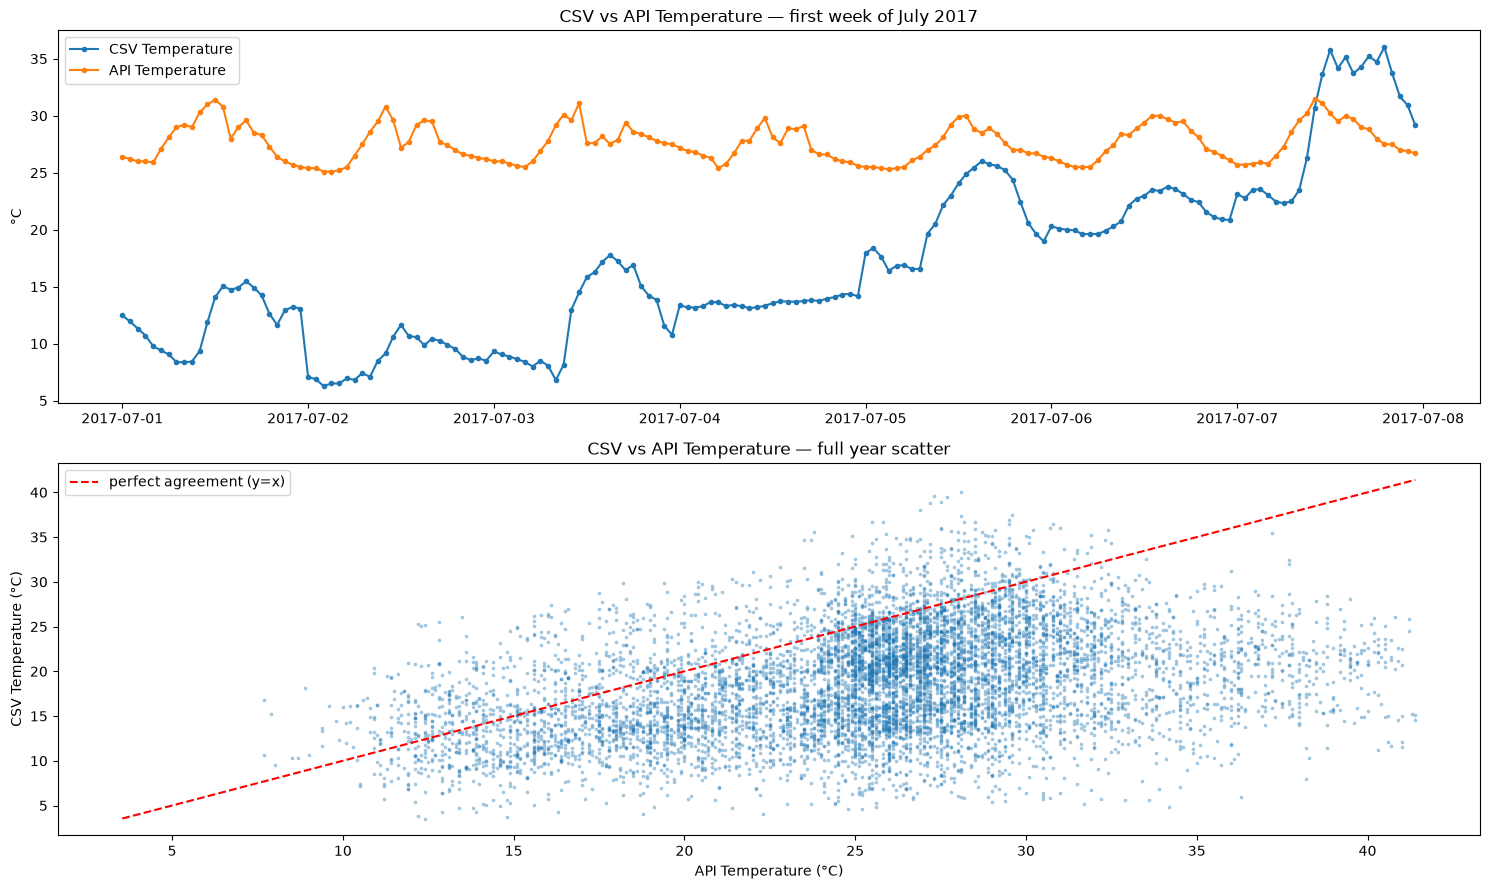

In [7]:
# === Cell 22: Visualize the agreement — one week, and a scatter ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# (a) One week overlaid: do they track the same daily rhythm?
sample = merged.loc['2017-07-01':'2017-07-07']
axes[0].plot(sample.index, sample['Temperature'], label='CSV Temperature', marker='.')
axes[0].plot(sample.index, sample['api_temperature'], label='API Temperature', marker='.')
axes[0].set_title("CSV vs API Temperature — first week of July 2017")
axes[0].set_ylabel("°C"); axes[0].legend()

# (b) Scatter across the whole year: tight diagonal = strong agreement
axes[1].scatter(merged['api_temperature'], merged['Temperature'], s=3, alpha=0.3)
lims = [merged[['api_temperature','Temperature']].min().min(),
        merged[['api_temperature','Temperature']].max().max()]
axes[1].plot(lims, lims, 'r--', label='perfect agreement (y=x)')
axes[1].set_xlabel("API Temperature (°C)"); axes[1].set_ylabel("CSV Temperature (°C)")
axes[1].set_title("CSV vs API Temperature — full year scatter")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# === Cell 23: Align hourly API cloud cover to the 10-minute power timeline ===
import pandas as pd

# API cloud cover, indexed by time (hourly)
cloud = weather.set_index('time')['api_cloudcover'].copy()
cloud.index = pd.to_datetime(cloud.index)

# Reindex onto our 10-minute timeline and forward-fill within each hour
cloud_10min = cloud.reindex(df.index, method='ffill')

print("Cloud cover aligned to 10-min grid.")
print("Length matches df:", len(cloud_10min) == len(df))
print("Missing after alignment:", cloud_10min.isna().sum())
print("\nFirst 8 aligned values (should hold steady across each hour):")
print(cloud_10min.head(8))

# Attach to df
df['CloudCover'] = cloud_10min
print("\ndf columns now:", list(df.columns))
print("CloudCover stats:", df['CloudCover'].describe()[['min','mean','max']].to_dict())

Cloud cover aligned to 10-min grid.
Length matches df: True
Missing after alignment: 0

First 8 aligned values (should hold steady across each hour):
Datetime
2017-01-01 00:00:00    18
2017-01-01 00:10:00    18
2017-01-01 00:20:00    18
2017-01-01 00:30:00    18
2017-01-01 00:40:00    18
2017-01-01 00:50:00    18
2017-01-01 01:00:00    23
2017-01-01 01:10:00    23
Name: api_cloudcover, dtype: int64

df columns now: ['Temperature', 'Humidity', 'WindSpeed', 'F1_132KV_PowerConsumption', 'F2_132KV_PowerConsumption', 'F3_132KV_PowerConsumption', 'Total_Demand', 'CloudCover']
CloudCover stats: {'min': 0.0, 'mean': 44.02964743589744, 'max': 100.0}


In [9]:
# === Cell 24: Install the holidays library into the venv ===
import sys
!{sys.executable} -m pip install holidays
print("Done.")

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.5 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.2 MB/s  0:00:00
Done.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# === Cell 25: Inspect India 2017 holidays (national + Jharkhand state) ===
import holidays

# India holidays for 2017, including Jharkhand state-specific ones where available
in_holidays = holidays.India(years=2017, subdiv='JH')   # JH = Jharkhand

print(f"Total holidays found for India/Jharkhand 2017: {len(in_holidays)}\n")
for date, name in sorted(in_holidays.items()):
    print(f"{date}  ({date.strftime('%A')})  -  {name}")

Total holidays found for India/Jharkhand 2017: 17

2017-01-26  (Thursday)  -  Republic Day
2017-02-24  (Friday)  -  Maha Shivaratri
2017-04-09  (Sunday)  -  Mahavir Jayanti
2017-04-14  (Friday)  -  Dr. B. R. Ambedkar's Jayanti; Good Friday
2017-05-10  (Wednesday)  -  Buddha Purnima
2017-06-26  (Monday)  -  Id-ul-Fitr
2017-08-15  (Tuesday)  -  Independence Day; Janmashtami
2017-09-02  (Saturday)  -  Bakrid
2017-09-30  (Saturday)  -  Dussehra
2017-10-01  (Sunday)  -  Muharram
2017-10-02  (Monday)  -  Gandhi Jayanti
2017-10-19  (Thursday)  -  Diwali
2017-10-26  (Thursday)  -  Chhath Puja
2017-11-04  (Saturday)  -  Guru Nanak Jayanti
2017-11-15  (Wednesday)  -  Jharkhand Formation Day
2017-12-02  (Saturday)  -  Milad-un-Nabi
2017-12-25  (Monday)  -  Christmas


In [12]:
# === Cell 26: Add a binary holiday flag to the 10-minute timeline ===
import holidays

# Build the 2017 India/Jharkhand holiday set
in_holidays = holidays.India(years=2017, subdiv='JH')

# Flag each row: 1 if its date is a holiday, else 0
# df.index.date gives the calendar date of each timestamp
df['IsHoliday'] = pd.Series(
    [1 if d in in_holidays else 0 for d in df.index.date],
    index=df.index
)

# Verify
n_holiday_rows = df['IsHoliday'].sum()
expected_rows = 17 * 144   # 17 holidays * 144 ten-min blocks per day
print("Holiday rows flagged:", n_holiday_rows)
print("Expected (17 holidays * 144 blocks):", expected_rows)
print("Match:", n_holiday_rows == expected_rows)

# Show the distinct holiday dates that got flagged
flagged_dates = sorted(set(d for d in df.index.date if d in in_holidays))
print("\nDistinct holiday dates flagged:", len(flagged_dates))
print(flagged_dates)

print("\ndf columns now:", list(df.columns))

Holiday rows flagged: 2448
Expected (17 holidays * 144 blocks): 2448
Match: True

Distinct holiday dates flagged: 17
[datetime.date(2017, 1, 26), datetime.date(2017, 2, 24), datetime.date(2017, 4, 9), datetime.date(2017, 4, 14), datetime.date(2017, 5, 10), datetime.date(2017, 6, 26), datetime.date(2017, 8, 15), datetime.date(2017, 9, 2), datetime.date(2017, 9, 30), datetime.date(2017, 10, 1), datetime.date(2017, 10, 2), datetime.date(2017, 10, 19), datetime.date(2017, 10, 26), datetime.date(2017, 11, 4), datetime.date(2017, 11, 15), datetime.date(2017, 12, 2), datetime.date(2017, 12, 25)]

df columns now: ['Temperature', 'Humidity', 'WindSpeed', 'F1_132KV_PowerConsumption', 'F2_132KV_PowerConsumption', 'F3_132KV_PowerConsumption', 'Total_Demand', 'CloudCover', 'IsHoliday']


In [13]:
# === Cell 27: Save the enriched dataset (cleaned + weather + holidays) ===
import os

out_dir = "../data/processed"
out_path = os.path.join(out_dir, "utility_enriched.csv")
df.to_csv(out_path)

print("Saved enriched data to:", os.path.abspath(out_path))
print("Shape:", df.shape)
print("Columns:", list(df.columns))

# Reload check
check = pd.read_csv(out_path, index_col='Datetime', parse_dates=['Datetime'])
print("\nReloaded shape:", check.shape, "| index dtype:", check.index.dtype)
print("CloudCover present:", 'CloudCover' in check.columns,
      "| IsHoliday present:", 'IsHoliday' in check.columns)

Saved enriched data to: c:\Project1\apu-load-forecasting\data\processed\utility_enriched.csv
Shape: (52416, 9)
Columns: ['Temperature', 'Humidity', 'WindSpeed', 'F1_132KV_PowerConsumption', 'F2_132KV_PowerConsumption', 'F3_132KV_PowerConsumption', 'Total_Demand', 'CloudCover', 'IsHoliday']

Reloaded shape: (52416, 9) | index dtype: datetime64[us]
CloudCover present: True | IsHoliday present: True


## Phase 2 — External Feature Integration (Weather & Holidays)

### Weather API integration (Open-Meteo Historical Archive)
- Sourced full-year 2017 hourly weather for Dhanbad, Jharkhand (23.7957°N, 86.4304°E):
  temperature, humidity, wind speed, and **cloud cover**. Open-Meteo was chosen over
  OpenWeatherMap because it provides free, key-less access to 2017 historical reanalysis data.
- Data cached locally (`data/raw/dhanbad_weather_2017.csv`) for reproducibility.

### Key finding: API weather does NOT match the dataset's own weather
- Reconciled the API weather against the CSV's weather columns on a shared hourly grid.
- Correlations were weak: Temperature 0.37, Humidity 0.21, WindSpeed 0.03.
- Physical check: the CSV reports single-digit °C temperatures in July (peak Indian summer),
  while Dhanbad's real July temperatures (API) are ~25–31°C. The two sources describe
  different climatic conditions — they are not the same location/period.
- **Implication:** the CSV weather is internally consistent with the demand series it
  accompanies; the API weather is not. Using mismatched weather as a model feature would
  degrade accuracy by introducing variables unlinked to the actual demand drivers.

### Decision (evidence-based)
- **Primary weather features:** the CSV's own Temperature, Humidity, WindSpeed.
- **Added from API:** CloudCover (no CSV equivalent; treated as a low-confidence feature,
  to be validated via model feature importance).
- The API integration is fully demonstrated and documented; the reconciliation analysis
  itself is a deliverable, not a discarded step.

### Holidays
- Generated the 2017 India + Jharkhand (subdiv='JH') public-holiday calendar via the
  `holidays` library: 17 holidays, including state-specific Chhath Puja and Jharkhand
  Formation Day. Added a binary `IsHoliday` flag (2,448 rows flagged).

### Enriched dataset
- Saved to `data/processed/utility_enriched.csv` — 9 columns
  (6 original + Total_Demand + CloudCover + IsHoliday).